In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [10]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages, BaseMessage
from langchain_core.documents import Document
from langchain_core.messages import ToolMessage
from pydantic import BaseModel, Field

class llm_schema(BaseModel):
    type: str = Field(description="Type of policy(Cancellation, Refund, Return, Warranty, shipping etc)")
    question: str = Field(description="Reframed sentence into which type of poilcy(Cancellation, Refund, Return, Warranty, shipping) should be check for eligibility")
    product_info: str = Field(description="Product name, product buying date(in dd/mm/yyy format), product/order id etc")

class graph_schema(TypedDict):
    query: Annotated[List[BaseMessage], add_messages]
    document: List[Document]
    product_info: str
    policy_question: str
    answer: str


In [11]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [12]:
from langchain_core.tools import tool

@tool
def retriever_embedding_tool():
    """
    Retrieve relevant information from a specific local document.
    
    Use this tool when the user asks a question about a PDF, DOCX,
    TXT, Markdown file, or other provided document.
    
    Args:
        question: The exact question to answer using the document.
        path: The complete filesystem path to the document.
        web_link : Link that will be used to fecth information
    """

In [13]:
tools = []

llm_with_tools = llm.bind_tools(tools)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
import os
from RagIntegration import RagRetriever

retriever = RagRetriever()
def retriever_node(state:graph_schema) -> graph_schema:

    query = state["query"][-1].content
    result = llm_with_schema.invoke(query)

    policy_dir = "Policies"

    policy_files = {
        "Return": "RETURN_POLICY.pdf",
        "Cancellation": "CANCELLATION_POLICY.pdf",
        "Refund": "REFUND_POLICY.pdf",
        "Warranty": "WARRANTY_POLICY.pdf",
        "Shipping": "SHIPPING_POLICY.pdf",
        "Payment": "PAYMENT_FAQ.pdf"
    }

    file_path = os.path.join(
        policy_dir,
        policy_files[result.type]
    )

    print("Loading:", file_path)
    print("Exists:", os.path.exists(file_path))

    retriever.file_loader(file_path)
    retriever.text_splitting()
    response = retriever.vector_embedding(result.question)

    return {
        "policy_question": result.question,
        "document": response,
        "product_info": result.product_info
    }

def tool_node(state: graph_schema) -> graph_schema:
    query = state['question']

    tool_by_name = {tool.name: tool for tool in tools}

    tool_result = []

    for tool_calls in query[-1].tool_calls:
        tool = tool_by_name[tool_calls["name"]]
        observation = tool.invoke(tool_calls["args"])
        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_calls["id"]))

    return {
        "document": tool_result
    }

def generator_node(state: graph_schema) -> graph_schema:
    user_query = state["query"][-1].content
    document = state["document"]
    question = state["policy_question"]
    product_info = state["product_info"]

    context = "\n\n".join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
    ("system", """
        You are a customer support assistant for an e-commerce company.

        Your task is to answer the user's original question using:
        1. The retrieved company policy as the authoritative source for policy rules.
        2. The customer's product/order information when determining eligibility.
        3. The original user question to understand what the customer wants.

        Instructions:
        - Use the retrieved policy as the source of truth for company rules.
        - Use the product/order information only for facts about the customer's specific product or order.
        - Compare the customer's product/order information against the requirements in the policy when determining eligibility.
        - Do not invent policy rules, customer information, order information, dates, prices, or eligibility conditions.
        - If the policy does not provide enough information to determine eligibility, clearly state that you cannot determine eligibility from the available information.
        - If the customer's product/order information is missing, ask the customer for the required information.
        - If the customer is eligible, clearly explain why based on the policy.
        - If the customer is not eligible, clearly explain which policy requirement is not satisfied.
        - Answer the original user's question, not merely the reframed policy question.
        - Keep the response clear and direct.
        - Do not mention the RAG system, retrieval process, embeddings, vector database, or internal tools.

        Retrieved Policy Context:
        {context}

        Customer/Product Information:
        {product_info}

        Policy_question:
        {question}
    """),

    ("user", """
        Original Customer Question:
        {user_query}
    """)
])

    chain = prompt | llm

    result = chain.invoke({"context": context, "product_info": product_info, "question": question, "user_query": user_query})

    return {
        "answer": result.content
    }

def tool_needed(state: graph_schema) -> str:
    if state['question'][-1].tool_calls:
        return "tool_node"
    else:
        return "end"


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2067.57it/s]


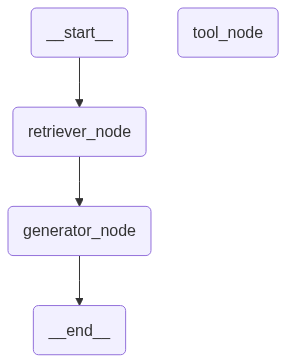

In [15]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("tool_node", tool_node)
graph.add_node("generator_node", generator_node)

graph.add_edge(START, "retriever_node")
#graph.add_conditional_edges("llm_node", tool_needed, {"tool_node": "tool_node", "end": END})
graph.add_edge("retriever_node", "generator_node")
graph.add_edge("generator_node", END)

customer_support_agent = graph.compile()

customer_support_agent

In [16]:
response = customer_support_agent.invoke({
    "query": "I want to return a laptop i bought 5 days ago",
    "document": [],
    "policy_question":"",
    "product_info": "",
    "answer": ""
})

response

Loading: Policies\RETURN_POLICY.pdf
Exists: True


KeyError: "Input to ChatPromptTemplate is missing variables {'question'}.  Expected: ['context', 'product_info', 'question', 'user_query'] Received: ['context', 'product_info', 'policy_question', 'user_query']\nNote: if you intended {question} to be part of the string and not a variable, please escape it with double curly braces like: '{{question}}'.\nFor troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/INVALID_PROMPT_INPUT "

In [ ]:
import os

print(os.getcwd())
print(os.path.exists("Policies/RETURN_POLICY.pdf"))

c:\FAHEEM\My_Programs\RAG_Beginners\customer_support_agent
True
